# Random Forest Classification - Tutorial

source: https://www.datacamp.com/tutorial/random-forests-classifier-python?dc_referrer=https%3A%2F%2Fwww.google.com%2F

In [1]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [2]:
# data from other tutorial (https://towardsdatascience.com/understanding-random-forest-using-python-scikit-learn/)
url = 'https://raw.githubusercontent.com/mGalarnyk/Tutorial_Data/master/King_County/kingCountyHouseData.csv'

df = pd.read_csv(url)
columns = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price']
df = df[columns]

In [3]:
# some own modifications
q25, q75 = df["price"].quantile([0.25, 0.75])
df = df[(df["price"] <= q25) | (df["price"] >= q75)]
df["high_cost"] = (df["price"] >= q75).astype(int)
df = df.drop(columns='price')
df

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,high_cost
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,0
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,47.6561,-122.005,4760,101930,1
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,47.3097,-122.327,2238,6819,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,47.4095,-122.315,1650,9711,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21597,4,3.25,3410,10125,2.0,0,0,3,10,3410,0,2007,0,47.5653,-122.223,2290,10125,1
21599,4,3.00,3990,7838,2.0,0,0,3,9,3990,0,2003,0,47.6857,-122.046,3370,6814,1
21600,5,3.75,4470,8088,2.0,0,0,3,11,4470,0,2008,0,47.6321,-122.200,2780,8964,1
21602,3,1.75,1500,11968,1.0,0,0,3,6,1500,0,2014,0,47.3095,-122.002,1320,11303,0


## Splitting the Data

In [4]:
# Split the data into features (X) and target (y)
X = df.drop(columns='high_cost', axis=1)
y = df['high_cost']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Fitting and Evaluating the Random Forest Model

In [5]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9898336414048059


## Visualizing the Results

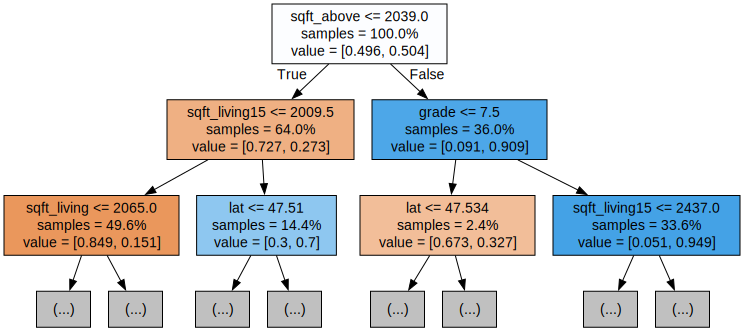

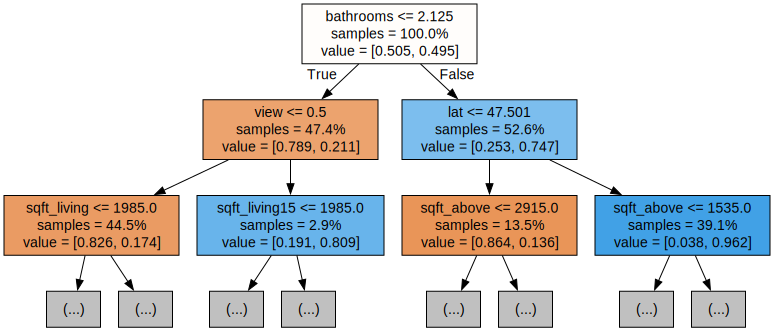

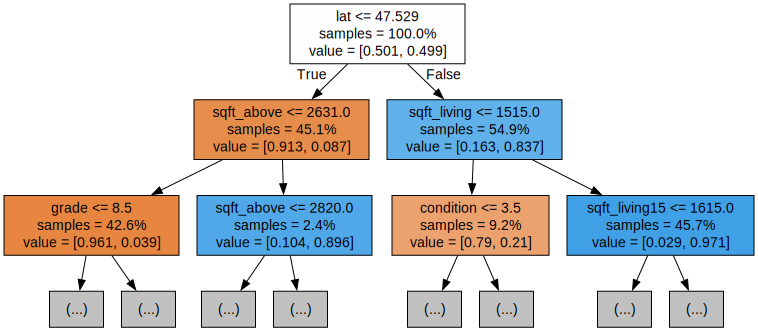

In [7]:
# Export the first three decision trees from the forest

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

## Hyperparameter Tuning

In [8]:
param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5)
}


# Create a random forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
  rf, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  n_jobs=-1, random_state=42
)

# Fit the RandomizedSearchCV on your training data
rand_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....x78ad5b5591e0>, 'min_samples_leaf': <scipy.stats....x78ad5b55a050>, 'min_samples_split': <scipy.stats....x78ad5b559630>, 'n_estimators': <scipy.stats....x78ad5b4b4370>}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [9]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 14, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 485}


## More Random Forest Evaluation Metrics

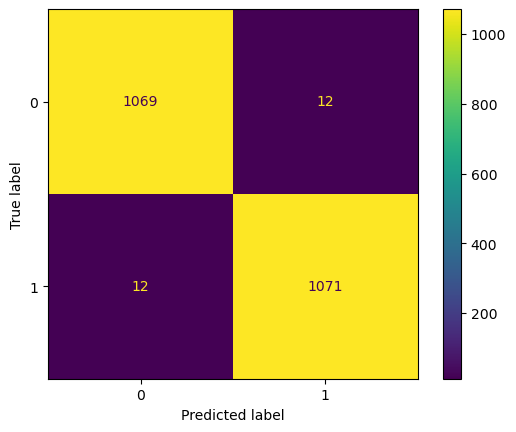

In [10]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [11]:
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.988909426987061
Precision: 0.9889196675900277
Recall: 0.9889196675900277


<Axes: >

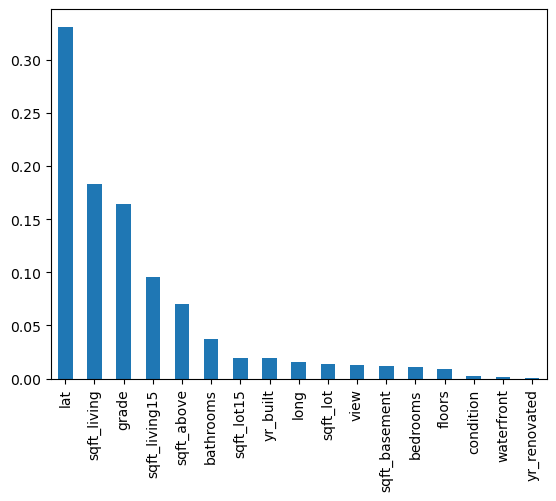

In [12]:
# Create a series containing feature importances from the model and feature names from the training data
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar()
